# E-Commerce Business Analysis

This project analyzes the Brazilian Olist E-commerce dataset to uncover business insights related to revenue trends, customer behavior, product performance, and delivery impact on customer satisfaction.

The goal is to transform raw data into actionable insights that can support business decisions.

## Executive Summary

This project analyzes the Brazilian Olist E-Commerce dataset to uncover key business insights related to revenue performance, customer behavior, product demand, and operational efficiency. The objective is to transform raw transactional data into actionable insights that support strategic decision-making.

The analysis follows a full end-to-end analytics workflow including data integration, cleaning, feature engineering, exploratory data analysis (EDA), and customer segmentation using the RFM framework.

### Key Findings

**1. Strong Revenue Growth Trend**
Monthly revenue shows a consistent upward trend, indicating increasing marketplace adoption and customer activity over time. The growth in the number of orders closely mirrors the revenue increase, suggesting that platform expansion is primarily driven by higher transaction volume.

**2. Dominance of Credit Card Payments**
Credit cards represent the majority of payment transactions on the platform, significantly outperforming other payment methods such as boleto, voucher, and debit card. This indicates strong customer preference for fast and convenient digital payment options.

**3. High-Performing Product Categories**
Product categories such as **Health & Beauty**, **Watches & Gifts**, and **Bed, Bath & Table** generate the highest revenue. These categories demonstrate strong and consistent demand and represent key revenue drivers for the platform.

**4. Delivery Performance Impacts Customer Satisfaction**
Analysis shows a clear relationship between delivery time and review scores. Orders delivered faster tend to receive significantly higher ratings, while delayed deliveries correlate with lower customer satisfaction. This highlights the importance of efficient logistics operations.

**5. Geographic Revenue Concentration**
A large portion of total revenue is concentrated in a small number of states, particularly **São Paulo (SP)** and **Rio de Janeiro (RJ)**. These regions represent the platform’s core markets and account for a significant share of customer transactions.

**6. Customer Segmentation Insights (RFM Analysis)**
Customer segmentation using the Recency-Frequency-Monetary model reveals multiple behavioral groups including Champions, Loyal Customers, Frequent Customers, and At-Risk Customers. While loyal and frequent customers contribute substantially to revenue, a large portion of customers fall into the At-Risk category, suggesting opportunities for retention strategies.

### Strategic Business Recommendations

• **Improve delivery efficiency** in regions experiencing long delivery times to increase customer satisfaction and reduce negative reviews.

• **Invest marketing efforts in high-revenue product categories** to maximize return on advertising and promotional campaigns.

• **Implement retention campaigns** targeting At-Risk customers through personalized promotions and loyalty incentives.

• **Expand marketplace penetration** in high-performing states while exploring growth opportunities in underperforming regions.

• **Encourage digital payment adoption** to streamline checkout processes and improve the overall customer experience.

Overall, this analysis demonstrates how data-driven insights can guide strategic decisions that enhance revenue growth, optimize operational performance, and improve customer satisfaction in a competitive e-commerce environment.


## Data Loading

In this step, we upload and access the e-commerce dataset files. These datasets contain information about orders, customers, products, sellers, payments, and reviews.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_customers_dataset.csv to olist_customers_dataset.csv


In [3]:
import os
os.listdir()

['.config',
 'olist_products_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_customers_dataset.csv',
 'product_category_name_translation.csv',
 'olist_orders_dataset.csv',
 'sample_data']

## Loading Individual Datasets

Each dataset represents a specific part of the e-commerce ecosystem:

- **Orders**: information about customer purchases
- **Order Items**: details of products included in each order
- **Products**: product catalog information
- **Customers**: customer location and identifiers
- **Payments**: payment methods and transaction values
- **Reviews**: customer feedback and ratings
- **Sellers**: seller information
- **Geolocation**: geographic data related to customers and sellers

Loading these datasets allows us to explore their structure before merging them for analysis.

In [4]:
import pandas as pd
sellers=pd.read_csv("olist_sellers_dataset.csv")
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [5]:
order_reviews=pd.read_csv("olist_order_reviews_dataset.csv")
order_reviews.head()


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [6]:
order_items=pd.read_csv("olist_order_items_dataset.csv")
order_items.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
geolocation=pd.read_csv("olist_geolocation_dataset.csv")
geolocation.head()


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [8]:
orders=pd.read_csv("olist_orders_dataset.csv")
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
product_category=pd.read_csv("product_category_name_translation.csv")
product_category.head()


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
order_payments=pd.read_csv("olist_order_payments_dataset.csv")
order_payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [11]:
products=pd.read_csv("olist_products_dataset.csv")
products.head()


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [12]:
customers=pd.read_csv("olist_customers_dataset.csv")
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [13]:
datasets = {
    "sellers": sellers,
    "order_reviews": order_reviews,
    "order_items": order_items,
    "geolocation": geolocation,
    "orders": orders,
    "product_category": product_category,
    "order_payments": order_payments,
    "products": products,
    "customers": customers
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

sellers: (3095, 4)
order_reviews: (99224, 7)
order_items: (112650, 7)
geolocation: (1000163, 5)
orders: (99441, 8)
product_category: (71, 2)
order_payments: (103886, 5)
products: (32951, 9)
customers: (99441, 5)


## Data Integration

To perform meaningful analysis, we merge the different datasets into a single dataframe that contains order, product, customer, and payment information.

In [14]:
df = orders.merge(order_items, on="order_id", how="left")
df.shape

(113425, 14)

In [15]:
df = df.merge(products, on="product_id", how="left")
df.shape

(113425, 22)

In [16]:
df = df.merge(product_category, on="product_category_name", how="left")
df.shape

(113425, 23)

In [17]:
df = df.merge(customers, on="customer_id", how="left")
df.shape

(113425, 27)

In [18]:
df = df.merge(order_payments, on="order_id", how="left")
df.shape

(118434, 31)

In [19]:
df = df.merge(order_reviews, on="order_id", how="left")
df.shape

(119143, 37)

In [20]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   order_item_id                  118310 non-null  float64
 9   product_id                     118310 non-null  object 
 10  seller_id                      118310 non-null  object 
 11  shipping_limit_date            118310 non-null  object 
 12  price                         

## Data Cleaning

We filter the dataset to include only delivered orders to ensure accurate revenue and delivery analysis.

In [21]:
df = df[df["order_status"] == "delivered"]
df.shape

(115723, 37)

In [71]:
df["order_status"] = df["order_status"].astype("category")
df["payment_type"] = df["payment_type"].astype("category")

## Converting Date Columns

Date columns are converted into datetime format to enable time-based analysis such as monthly revenue trends and delivery time calculations.

In [22]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

## Feature Engineering

We create new features that will help in the analysis, including:

- Order month
- Delivery time
- Total revenue

In [23]:
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")

In [24]:
df["delivery_time"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

## Total Revenue Calculation

In [25]:
df["total_revenue"] = df["payment_value"]

In [26]:
df["total_revenue"].sum()

np.float64(19881945.07)

In [27]:
df["order_id"].nunique()

96478

In [28]:
df["customer_unique_id"].nunique()

93358

### Insight

The total revenue represents the overall financial performance of the platform based on completed transactions.

The dataset contains a large number of unique orders and customers, indicating significant marketplace activity.

## Monthly Revenue Trend

Understanding how revenue evolves over time is essential for evaluating business growth.

This analysis aggregates total revenue by month to identify patterns in sales performance and overall platform expansion.

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='order_month'>

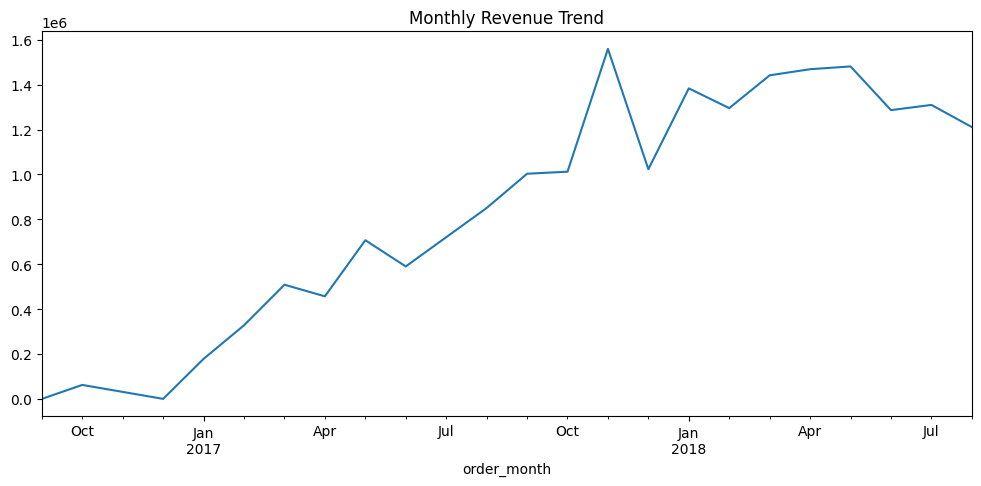

In [29]:
monthly_revenue = df.groupby("order_month")["total_revenue"].sum()

monthly_revenue.plot(figsize=(12,5), title="Monthly Revenue Trend")

### Insight

The monthly revenue trend shows a clear upward growth over time, indicating increasing customer demand and platform adoption.

This pattern suggests that the marketplace has successfully expanded its customer base and transaction volume.

In [30]:
df = df.dropna(subset=["payment_value"])

In [31]:
df["product_category_name_english"] = df["product_category_name_english"].fillna("Unknown")

In [32]:
df.duplicated().sum()

np.int64(0)

## Payment Value Distribution

Analyzing payment values helps understand how much customers typically spend per transaction.

This statistical summary provides insights into spending patterns and the variability of order values across the platform.

In [33]:
df["payment_value"].describe()

,payment_value
count,115720.000000
mean,171.810794
std,265.642619
min,0.000000
25%,60.850000
50%,108.110000
75%,188.940000
max,13664.080000


### Insight

The distribution of payment values shows significant variability in customer spending behavior. While most orders fall within a moderate price range, some transactions reach much higher values, indicating the presence of both small and high-value purchases on the platform.

## Delivery Time Analysis

In [34]:
df["delivery_time"].describe()

,delivery_time
count,115712.000000
mean,12.021139
std,9.452341
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


### Insight

The average delivery time is around 12 days, with most orders delivered between 6 and 15 days. However, some orders experience significantly longer delivery times, indicating variability in logistics performance.

## Highest Value Orders

In [36]:
df.sort_values("payment_value", ascending=False)[
    ["order_id", "payment_value", "product_category_name_english"]
].head(10)

,order_id,payment_value,product_category_name_english
15920,03caa2c082116e1d31e67e9ae3700499,13664.08,fixed_telephony
15919,03caa2c082116e1d31e67e9ae3700499,13664.08,fixed_telephony
15921,03caa2c082116e1d31e67e9ae3700499,13664.08,fixed_telephony
15914,03caa2c082116e1d31e67e9ae3700499,13664.08,fixed_telephony
15916,03caa2c082116e1d31e67e9ae3700499,13664.08,fixed_telephony
15915,03caa2c082116e1d31e67e9ae3700499,13664.08,fixed_telephony
15918,03caa2c082116e1d31e67e9ae3700499,13664.08,fixed_telephony
15917,03caa2c082116e1d31e67e9ae3700499,13664.08,fixed_telephony
79657,736e1922ae60d0d6a89247b851902527,7274.88,fixed_telephony
79658,736e1922ae60d0d6a89247b851902527,7274.88,fixed_telephony


### Insight

The highest-value orders belong mainly to the "fixed_telephony" product category, indicating that certain product categories generate significantly higher transaction values compared to others.

## Delivery Time Analysis

Delivery time is a critical performance indicator in e-commerce logistics.

Measuring the time between purchase and delivery helps evaluate operational efficiency and customer experience.

In [37]:
df.sort_values("delivery_time", ascending=False)[
    ["order_id", "delivery_time", "customer_state"]
].head(10)

,order_id,delivery_time,customer_state
23417,ca07593549f1816d26a572e06dc1eab6,209.0,ES
66581,1b3190b2dfa9d789e1f14c05b647a14a,208.0,RJ
73634,440d0d17af552815d15a9e41abe49359,195.0,PA
46165,0f4519c5f1c541ddec9f21b3bddd533a,194.0,PI
106627,285ab9426d6982034523a855f55a885e,194.0,SE
84056,2fb597c2f772eca01b1f5c561bf6cc7b,194.0,PI
13563,47b40429ed8cce3aee9199792275433f,191.0,SP
97345,2fe324febf907e3ea3f2aa9650869fa5,189.0,SP
65222,2d7561026d542c8dbd8f0daeadf67a43,188.0,SE
74421,437222e3fd1b07396f1d9ba8c15fba59,187.0,AP


### Insight

Some orders experience extremely long delivery times (over 180 days), indicating potential logistical delays or operational inefficiencies in certain cases.

## Total Revenue Calculation

To accurately calculate total revenue, we remove duplicate order entries and ensure that each order is counted only once.

Since an order may contain multiple items, the dataset can include repeated order IDs. Removing duplicates prevents revenue from being overestimated.

In [38]:
orders_revenue = df[["order_id", "payment_value"]].drop_duplicates()

orders_revenue["payment_value"].sum()

np.float64(15405164.11)

### Insight

The total revenue reflects the overall financial performance generated by completed transactions on the platform.

## Detecting Outliers in Payment Values

In [39]:
Q1 = df["payment_value"].quantile(0.25)
Q3 = df["payment_value"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-131.285), np.float64(381.075))

In [40]:
df_no_outliers = df[
    (df["payment_value"] >= lower_bound) &
    (df["payment_value"] <= upper_bound)
]

In [41]:
print("Original size:", df.shape)
print("Without outliers:", df_no_outliers.shape)

Original size: (115720, 40)
Without outliers: (106435, 40)


## Average Order Value (AOV)

In [42]:
orders_level = df.groupby("order_id")["payment_value"].max().reset_index()

AOV = orders_level["payment_value"].mean()
AOV

np.float64(158.34331830384446)

## Shipping Cost Ratio

In [43]:
df["shipping_ratio"] = df["freight_value"] / df["price"]

## Payment Value Normalization

In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["normalized_payment"]] = scaler.fit_transform(df[["payment_value"]])

## Date Dimension Table

In [45]:
date_dim = pd.DataFrame({
    "date": pd.date_range(
        start=df["order_purchase_timestamp"].min(),
        end=df["order_purchase_timestamp"].max()
    )
})

date_dim["year"] = date_dim["date"].dt.year
date_dim["month"] = date_dim["date"].dt.month
date_dim["month_name"] = date_dim["date"].dt.month_name()
date_dim["quarter"] = date_dim["date"].dt.quarter

date_dim.head()

,date,year,month,month_name,quarter
0,2016-10-03 09:44:50,2016,10,October,4
1,2016-10-04 09:44:50,2016,10,October,4
2,2016-10-05 09:44:50,2016,10,October,4
3,2016-10-06 09:44:50,2016,10,October,4
4,2016-10-07 09:44:50,2016,10,October,4


## Order-Level Revenue

In [46]:
orders_revenue = df.groupby("order_id")["payment_value"].max().reset_index()

## Item Revenue Calculation

In [47]:
df["item_revenue"] = df["price"] + df["freight_value"]

## Top Product Categories by Revenue

In [48]:
category_revenue = (
    df.groupby("product_category_name_english")["item_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_revenue

,item_revenue
product_category_name_english,
health_beauty,1461206.29
watches_gifts,1316696.84
bed_bath_table,1309729.85
sports_leisure,1166307.34
computers_accessories,1077483.63
furniture_decor,931754.14
housewares,801521.45
cool_stuff,722033.51
auto,698077.73


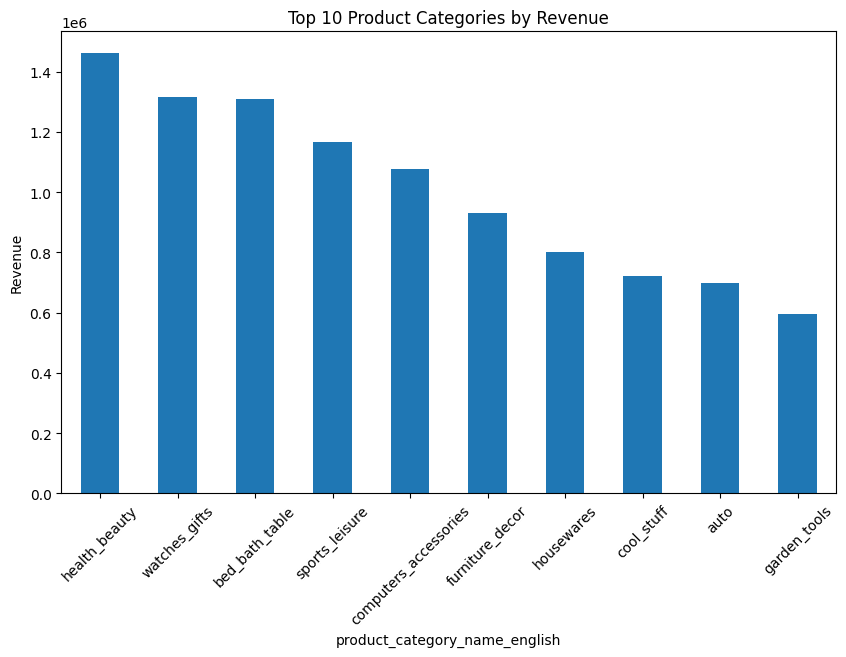

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
category_revenue.plot(kind="bar")
plt.title("Top 10 Product Categories by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Insight

Health & Beauty and Watches are among the highest revenue-generating categories, indicating strong demand for lifestyle and personal products.

## Revenue by State

In [50]:
state_revenue = (
    df.groupby("customer_state")["item_revenue"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10)

,item_revenue
customer_state,
SP,6076295.43
RJ,2167521.77
MG,1890600.24
RS,908920.14
PR,812671.95
BA,627081.41
SC,616385.81
DF,360530.87
GO,355374.39


### Insight

Revenue is highly concentrated in a few states such as SP, RJ, and MG, indicating that the majority of customers and transactions are located in these regions.

## Payment Method Distribution

In [51]:
payment_distribution = df["payment_type"].value_counts()

payment_distribution

,count
payment_type,
credit_card,85372
boleto,22505
voucher,6181
debit_card,1662


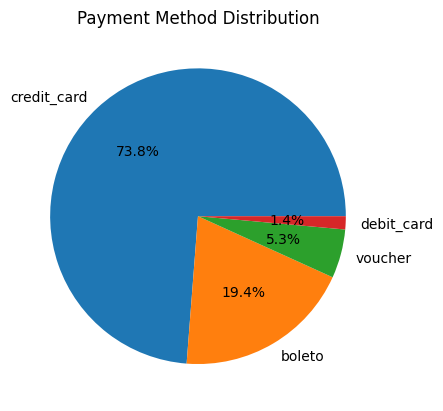

In [52]:
payment_distribution.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

### Insight

Credit cards dominate the payment methods, accounting for the majority of transactions.

## Delivery Time vs Review Score

This analysis examines the relationship between delivery time and customer review scores to understand how delivery performance affects customer satisfaction.

In [53]:
df.groupby("review_score")["delivery_time"].mean()

,delivery_time
review_score,
1.0,19.091582
2.0,15.381893
3.0,13.550731
4.0,11.778330
5.0,10.203350


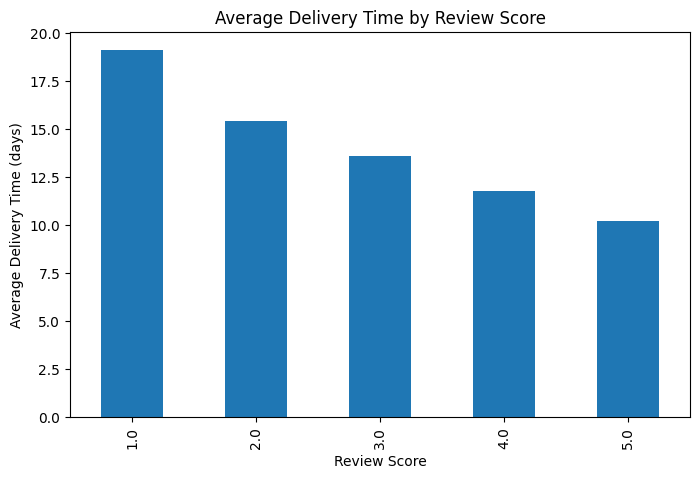

In [55]:
import matplotlib.pyplot as plt

review_delivery = df.groupby("review_score")["delivery_time"].mean()

plt.figure(figsize=(8,5))
review_delivery.plot(kind="bar")
plt.title("Average Delivery Time by Review Score")
plt.ylabel("Average Delivery Time (days)")
plt.xlabel("Review Score")
plt.show()

### Insight

Customers who experience faster delivery times tend to give higher review scores. Orders with lower ratings (1–2 stars) show significantly longer delivery times, indicating that delivery speed strongly influences customer satisfaction.

## Monthly Orders vs Revenue

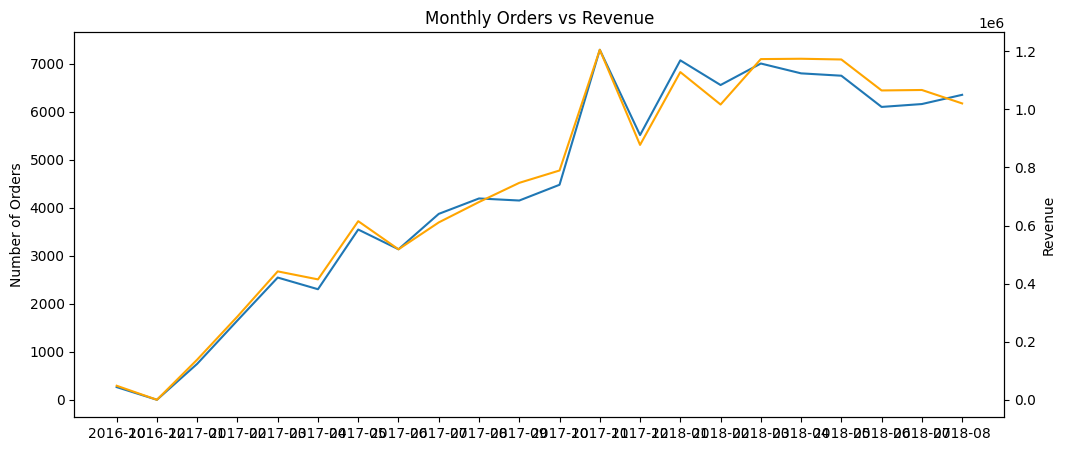

In [56]:
monthly_orders = df.groupby("order_month")["order_id"].nunique()
monthly_revenue = df.groupby("order_month")["item_revenue"].sum()

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(monthly_orders.index.astype(str), monthly_orders, label="Orders")
ax1.set_ylabel("Number of Orders")

ax2 = ax1.twinx()
ax2.plot(monthly_revenue.index.astype(str), monthly_revenue, color="orange", label="Revenue")
ax2.set_ylabel("Revenue")

plt.title("Monthly Orders vs Revenue")
plt.xticks(rotation=45)
plt.show()

### Insight

The increase in the number of orders closely follows the revenue trend, suggesting that business growth is driven by increased customer activity.

## Review Score Distribution

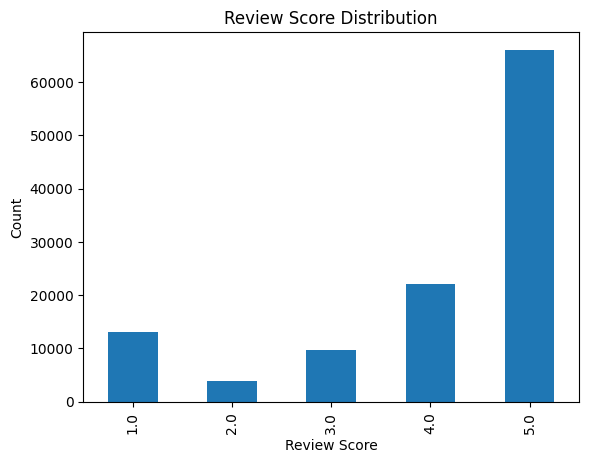

In [57]:
df["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

### Insight

Most customers provide high ratings (4–5), indicating generally positive customer satisfaction with the platform.

## Top Categories by Average Order Value

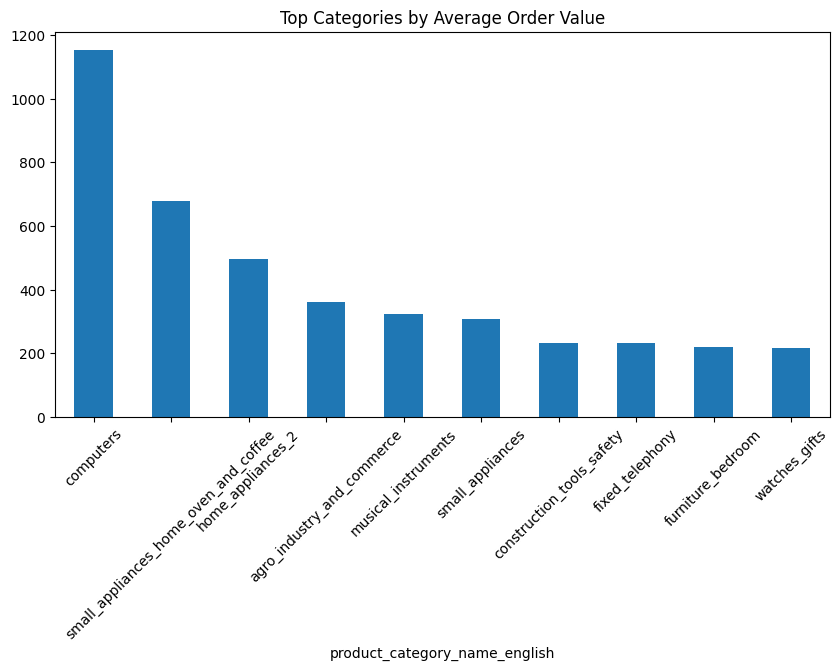

In [58]:
aov_category = (
    df.groupby("product_category_name_english")["item_revenue"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

aov_category.plot(kind="bar", figsize=(10,5))
plt.title("Top Categories by Average Order Value")
plt.xticks(rotation=45)
plt.show()

### Insight

Some categories generate fewer orders but higher average order values, making them highly profitable.

## Monthly Average Order Value

<Axes: title={'center': 'Monthly Average Order Value'}, xlabel='order_month'>

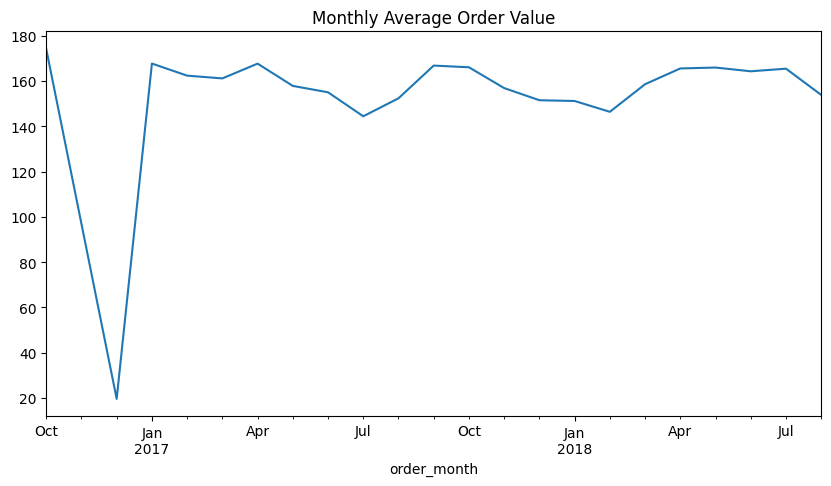

In [60]:
orders_level = df.groupby("order_id")["payment_value"].max().reset_index()

df_orders = df[["order_id", "order_month"]].drop_duplicates()
df_orders = df_orders.merge(orders_level, on="order_id")

monthly_aov = df_orders.groupby("order_month")["payment_value"].mean()

monthly_aov.plot(figsize=(10,5), title="Monthly Average Order Value")

### Insight

The average order value remains relatively stable over time, suggesting consistent purchasing behavior among customers.

## Customer Segmentation using RFM Analysis

RFM analysis segments customers based on their purchasing behavior using three metrics: Recency (how recently a customer purchased), Frequency (how often they purchase), and Monetary value (how much they spend).

In [61]:
orders_level = df.groupby(
    ["customer_unique_id", "order_id", "order_purchase_timestamp"]
)["payment_value"].max().reset_index()

In [62]:
import datetime as dt

snapshot_date = df["order_purchase_timestamp"].max() + dt.timedelta(days=1)

In [63]:
rfm = orders_level.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum"
}).reset_index()

rfm.columns = ["customer_id", "Recency", "Frequency", "Monetary"]

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [64]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

In [65]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [66]:
def segment_customer(row):
    if row["RFM_score"] == "555":
        return "Champions"
    elif row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Loyal Customers"
    elif row["R_score"] >= 4:
        return "Recent Customers"
    elif row["F_score"] >= 4:
        return "Frequent Customers"
    else:
        return "At Risk"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [67]:
rfm["Segment"].value_counts()

,count
Segment,
At Risk,33542
Recent Customers,22472
Frequent Customers,22382
Loyal Customers,13958
Champions,1003


<Axes: xlabel='Segment'>

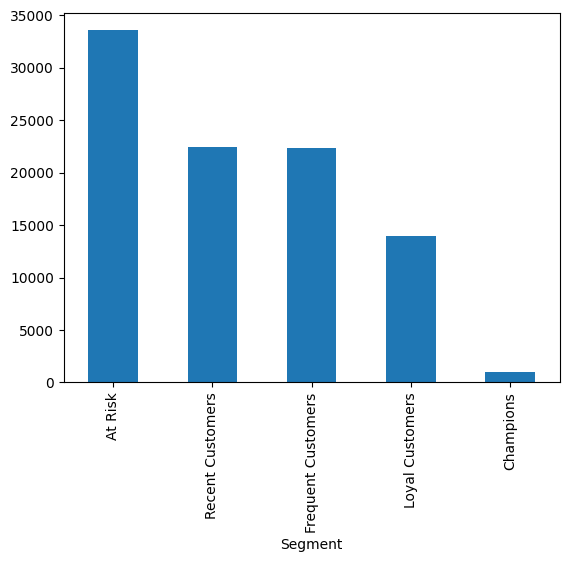

In [68]:
rfm["Segment"].value_counts().plot(kind="bar")

### Insight

Most customers fall into the "At Risk" and "Recent Customers" segments, indicating that a large portion of customers either purchased recently or may require engagement strategies to retain them. High-value customers such as "Champions" represent a smaller but very important group for long-term revenue.

## Customer Segmentation by Total Spending

In [69]:
customer_spending = df.groupby("customer_unique_id")["payment_value"].sum().reset_index()

customer_spending.columns = ["customer_id", "total_spent"]

customer_spending["segment"] = pd.qcut(
    customer_spending["total_spent"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

customer_spending.head()

,customer_id,total_spent,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,Medium Value
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,Low Value
2,0000f46a3911fa3c0805444483337064,86.22,Medium Value
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,Low Value
4,0004aac84e0df4da2b147fca70cf8255,196.89,High Value


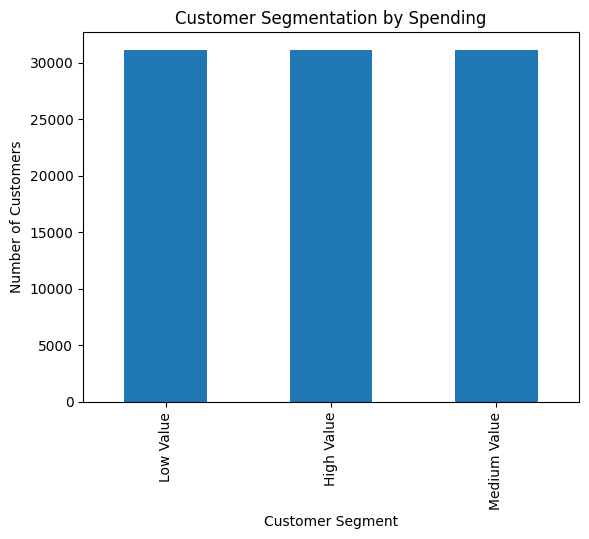

In [70]:
import matplotlib.pyplot as plt

customer_spending["segment"].value_counts().plot(kind="bar")

plt.title("Customer Segmentation by Spending")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

### Insight

Customers are distributed across three spending segments: Low Value, Medium Value, and High Value. High-value customers contribute significantly to overall revenue, while low-value customers represent opportunities for targeted promotions and upselling strategies.

## Final Business Insights

The analysis of the Olist e-commerce dataset revealed several important insights about the platform’s performance, customer behavior, and operational efficiency.

• The platform experienced consistent revenue growth over time, indicating increasing marketplace adoption and transaction activity.

• Product categories such as Health & Beauty and Watches & Gifts are major contributors to total revenue, highlighting strong demand for lifestyle-related products.

• Credit cards dominate the payment ecosystem, accounting for the majority of transactions across the platform.

• Delivery performance plays a critical role in customer satisfaction, as faster delivery times are strongly associated with higher review scores.

• Customer segmentation using the RFM model reveals distinct behavioral groups, including Champions, Loyal Customers, and At-Risk customers.

These findings provide a comprehensive understanding of the platform’s growth patterns, customer preferences, and operational performance.

In [72]:
df.to_csv("ecommerce_clean_dataset.csv", index=False)